Use this script to look at the fraction of tuned cells to %escape in different conditions after removing cells whose tuning can be explained by distance to shelter in exploration or homing/escape 

We aim to compare which cells are tuned across conditions and what they are tuned to across conditions

- sig tuned to %escape and shelter distance in explore
- sig tuned to %escape and shelter distance in homing/escape
- triple overlap cells

In [1]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

# JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
# "JAL3_7sept", "JAL3_4sept", "JAL3_1sept", "JAL3_25aug", "JAL3_22aug",

experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, JAL6_flip5_25mar, # (unmatched number of neurons and cluster ids) # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_14may, JAL8_flip4_10may]

session_names = ["JAL4_3rdSept","JAL4_19thSept","JAL4_28aug","JAL4_11thSept",
    "JAL5_8thSept","JAL5_21stSept",
    "JAL6_28mar", "JAL6_flip4_21mar", "JAL6_flip3_18mar", "JAL6_flip5_25mar", 
    "JAL7_sesh8_9apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_sesh9_16apr", "JAL7_23apr",
    "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip3_7may",  "JAL8_14may", "JAL8_flip4_10may"] 

In [68]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.process.process import Process
from JR_test_scripts.escape.escape_utils import load, load_homing
from JR_test_scripts.escape.escape_tuning_funcs import tuning_method
from JR_test_scripts.escape.escape_data_loading_funcs import extract_homing_and_escape_periods
from JR_test_scripts.FigureSaver import Figure_Saver

import os
import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from pathlib import Path
import dill as pickle
from itertools import product
from scipy.stats import zscore
from scipy.ndimage import gaussian_filter1d
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 20
matplotlib.rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded in PDF

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
"""Some preset variables"""

case = 'either_tuned' # 'escape_tuned', 'dist_tuned', 'either_tuned
var = 'escape' # 'dist', 'escape'
condition = 'all' # 'shelter_only', 'barrier', 'flipped_barrier', 'all', 'barrier_both'
explore_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves_explore/")
homie_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
save_path = make_directory("Z:/Jasmine_Laurence/summary_plots/Cosyne/")
cond = [[0,0,1],[1,2,2]]
c_names = ['shelter_only', 'barrier', 'flipped_barrier']
title_c_names = ['Shelter only', 'Barrier', 'Flipped barrier']
cond_colors = ['#228B22','#FF8C00','#008B8B']
tuning_data = '_25bins' # '' or '_50bins'

In [4]:
"""Load in hdir cells"""
dir = Path("Z:\Jasmine_Laurence\single_trial_overview\decoding_spatial_efficiency\head_direction_cells.pkl")
with open(dir, "rb") as dill_file:
    hdir = pickle.load(dill_file)

hdir_sesh = []

for idx, exp in enumerate(experiments_objects):
    session = Process(exp).load_session()
    base_path = os.path.join(session.base_path, session.processed_path)
    clu_Ids = np.load(os.path.join(session.base_path, session.processed_path)
        + "\\"
        + "good_cluster_Ids.npy"
    )

    hdir_n = hdir[session_names[idx]]
    hdir_sesh.append([int(np.where(clu_Ids == h)[0][0]) for h in hdir_n])

C:\Users\Jasmine\AppData\Local\Temp\ipykernel_26068\1604116611.py:147: RuntimeWarning: invalid value encountered in divide
  hist_all[e,:,idx] = hist_all[e,:,idx]/cum_cell
C:\Users\Jasmine\AppData\Local\Temp\ipykernel_26068\1604116611.py:150: RuntimeWarning: invalid value encountered in divide
  hist_goal[e,:,idx] = hist_goal[e,:,idx]/cum_cell
C:\Users\Jasmine\AppData\Local\Temp\ipykernel_26068\1604116611.py:153: RuntimeWarning: invalid value encountered in divide
  hist_2nd_leg[e,:,idx] = hist_2nd_leg[e,:,idx]/cum_cell


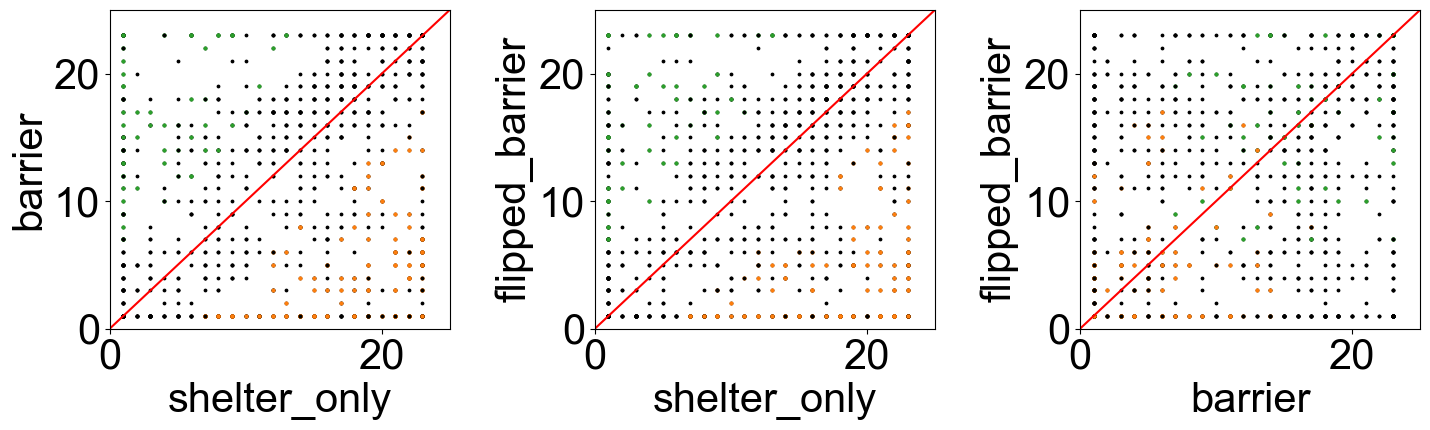

In [ ]:
"""How many cells are tuned only to the %escape and not to the distance to shelter in exploration?
Using residuals to identify tuning to %escape surviving from distance to shelter subtraction"""

if tuning_data == '':
    threshold = 10
    hist_bins = np.arange(-105,105,10)
    if case == 'escape_tuned':
        lim = [0,100]
    elif case == 'dist_tuned':
        lim = [0,80]
    elif case == 'either_tuned':
        if var == 'dist':
            lim = [0,80]
        elif var == 'escape':
            lim = [0,100]
else:
    lim = [0,25]
    hist_bins = np.arange(-27.5,27.6,5)
    threshold = 5

hist_all = np.full((len(experiments_objects),len(hist_bins)-1,3), np.nan)
hist_goal = np.full((len(experiments_objects),len(hist_bins)-1,3), np.nan)
hist_2nd_leg = np.full((len(experiments_objects),len(hist_bins)-1,3), np.nan)

fig, axs = plt.subplots(1, 3, figsize = (15, 5))
for idx, ax in enumerate(axs):
    ax.set_xlabel(c_names[cond[0][idx]])
    ax.set_ylabel(c_names[cond[1][idx]])
    ax.plot(lim,lim, color = 'red')
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    
for e, exp in enumerate(experiments_objects):
    nickname = exp.nick_name + '_' + exp.experiment_date

    # 1. load in explore tuning curve
    exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'bird_dist_shelter'
    data = np.load(explore_path + exp_nickname + '_Tuning' + tuning_data + '.npz')
    # identify cells that are sig tuned to distance to shelter in exploration
    exp_sig_dist = data['params_real'][:,:,0] > np.nanpercentile(data['params_shifts'][:,:,:,0], 95, axis = 0)

    # 2. load in escape homing/escape tuning curve
    exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
    data = np.load(homie_path + exp_nickname + '_ProperTuning' + tuning_data + '.npz')
    fr_esc = data['fr_full']
    fit_real = data['y_fitted_full']
    # identify cells that are sig tuned to %escape in homing/escape
    sig_escape = data['params_real'][:,:,0] > np.nanpercentile(data['params_shifts'][:,:,:,0], 95, axis = 0)
    params_esc = data['params_full']

    # 2. load in dist to shelter homing/escape tuning curve
    exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'bird_dist_shelter'
    data = np.load(homie_path + exp_nickname + '_ProperTuning' + tuning_data + '.npz')
    fr_dist = data['fr_full']
    # identify cells that are sig tuned to %escape in homing/escape
    sig_dist = data['params_real'][:,:,0] > np.nanpercentile(data['params_shifts'][:,:,:,0], 95, axis = 0)
    params_dist = data['params_full']

    # 4. load in residuals data
    exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
    data = np.load(homie_path + exp_nickname + '_ResidualsTuning' + tuning_data + '.npz')
    # find cells whose residual tuning to %escape - distance to shelter in exploration is significant
    sig_res = data['params_real_exp'][:,:,0] > np.nanpercentile(data['params_shifts_exp_res'][:,:,:,0], 95, axis = 0)

    # 5. pull out the vector of hdir cells
    hdir_cells = np.full(params_esc.shape[0], False)
    hdir_cells[hdir_sesh[e]] = True

    """Select the cells I want to analyse"""
    if case == 'escape_tuned':
        # cells that are tuned to %escape in homing/escape (subselect ones that are not tuned to distance to shelter in exploration and passed the residual test)
        xval = np.full_like(sig_escape, np.nan)
        for c in range(3):
            A = (sig_escape[:, c] == True) & (exp_sig_dist[:, c] == False) & (sig_res[:, c] == False)  # V1 only
            AC = (sig_escape[:, c] == True) & (sig_res[:, c] == True)  # Both V1 and V1 regressed
            xval[:,c] = (A == True) | (AC == True)

    if case == 'dist_tuned':
        # cells that are tuned to distance to shelter in homing/escape (subselect ones that are not tuned to %escape in homing/escape)
        xval = np.full_like(sig_escape, np.nan)
        for c in range(3):
            A = (sig_dist[:, c] == True)
            B = (sig_dist[:, c] == True) & (exp_sig_dist[:,c] == False)
            xval[:,c] = (A == True) # xval[:,c] = (B == True)
    
    if case == 'either_tuned':
        # cells that are tuned to distance to shelter or %escape in homing/escape (subselect ones that are not tuned to distance to shelter in exploration and passed the residual test)
        xval = np.full_like(sig_escape, np.nan)
        for c in range(3):
            A = (sig_escape[:, c] == True) & (exp_sig_dist[:, c] == False) & (sig_res[:, c] == False)
            AC = (sig_escape[:, c] == True) & (sig_res[:, c] == True) # Both V1 and V1 regressed
            B = (sig_dist[:, c] == True)
            xval[:,c] = (A == True) | (AC == True) | (B == True)

    # just falsify the cells that are hdir
    xval[hdir_cells,:] = np.full(3, False)

    # which conditions do we want the cells to be significant in?
    if condition == 'all':
        cells = np.sum(xval, axis = 1) == 3
    elif condition == 'shelter_only':
        cells = xval[:,0] == True
    elif condition == 'barrier':
        cells = xval[:,1] == True
    elif condition == 'flipped_barrier':
        cells = xval[:,2] == True
    elif condition == 'barrier_both':
        cells = (xval[:,0] == False) & (xval[:,1] == True) & (xval[:,2] == True)

    # select which tuning curve and params to use
    if case == 'escape_tuned':
        params = params_esc
        fr = fr_esc
    elif case == 'dist_tuned':
        params = params_dist
        fr = fr_dist[:,:,:80]
    elif case == 'either_tuned':
        if var == 'dist':
            params = params_dist
            fr = fr_dist[:,:,:80]
        elif var == 'escape':
            params = params_esc
            fr = fr_esc

    if e == 0:
        all_params = params
        all_cells = cells
        all_fr = fr
        all_fit = fit_real
        sesh_vector = np.full(params.shape[0], e)
    else:
        all_params = np.concatenate((all_params, params), axis = 0)
        all_cells = np.concatenate((all_cells, cells), axis = 0)
        all_fr = np.concatenate((all_fr, fr), axis = 1)
        all_fit = np.concatenate((all_fit, fit_real), axis = 1)
        sesh_vector = np.concatenate((sesh_vector, np.full(params.shape[0], e)), axis = 0)

    consistent_cells = (np.abs(params[:, 0, 1] - params[:, 1, 1]) < threshold) & (np.abs(params[:, 1, 1] - params[:, 2, 1]) < threshold)
    shelter_remap_goal = ((params[:, 0, 1] - params[:, 1, 1]) < - threshold) & ((params[:, 0, 1] - params[:, 2, 1]) < - threshold)
    shelter_remap_second_leg = ((params[:, 0, 1] - params[:, 1, 1]) > threshold) & ((params[:, 0, 1] - params[:, 2, 1]) > threshold)

    """Make a histogram of the difference in preferred tuning across conditions"""
    cond = [[0,0,1],[1,2,2]]
    for idx in range(3):
        diff = params[cells, cond[0][idx], 1] - params[cells, cond[1][idx], 1]
        hist_all[e,:,idx], _ = np.histogram(diff, bins = hist_bins)
        cum_cell = np.sum(hist_all[e,:,idx])
        hist_all[e,:,idx] = hist_all[e,:,idx]/cum_cell
        diff = params[cells & shelter_remap_goal, cond[0][idx], 1] - params[cells & shelter_remap_goal, cond[1][idx], 1]
        hist_goal[e,:,idx], _ = np.histogram(diff, bins = hist_bins)
        hist_goal[e,:,idx] = hist_goal[e,:,idx]/cum_cell
        diff = params[cells & shelter_remap_second_leg, cond[0][idx], 1] - params[cells & shelter_remap_second_leg, cond[1][idx], 1]
        hist_2nd_leg[e,:,idx], _ = np.histogram(diff, bins = hist_bins)
        hist_2nd_leg[e,:,idx] = hist_2nd_leg[e,:,idx]/cum_cell
    
    """Make a scatter plot of the preferred tuning of the cells across conditions"""
    
    for idx, ax in enumerate(axs):
        ax.scatter(params[cells, cond[0][idx], 1], params[cells, cond[1][idx], 1], s = 3, color = 'black')
        # ax.scatter(params[cells & consistent_cells, cond[0][idx], 1], params[cells & consistent_cells, cond[1][idx], 1], s = 4, color = 'blue') 
        ax.scatter(params[cells & shelter_remap_goal, cond[0][idx], 1], params[cells & shelter_remap_goal, cond[1][idx], 1], s = 4, color = 'C2')  
        ax.scatter(params[cells & shelter_remap_second_leg, cond[0][idx], 1], params[cells & shelter_remap_second_leg, cond[1][idx], 1], s = 4, color = 'C1')        
        # cells that are double peakes in one of the two conditions
        # doublets = (np.isnan(params[:, cond[0][idx], 4]) == False) | (np.isnan(params[:, cond[1][idx], 4]) == False)
        # ax.scatter(params[cells & doublets, cond[0][idx], 1], params[cells & doublets, cond[1][idx], 1], s = 3, color = 'red')

plt.tight_layout()

Groups of things we can look at:
1. Look at cells that are significant in all three conditions (or in 2/3 conditions)
    - what are they tuned to in each? make a heatmap of the sorted tuning curves
    - make sorted heatmaps of responses on different types of trials (homings to barrier, north vs south homings)
    - plot the preferred tuning aganst each other
2. Look at cells that are significant in one condition
    - basically a lot of the same types of plots

RH Warning: Overwriting file. File: \\ceph-gw02.hpc.swc.ucl.ac.uk\branco\Jasmine_Laurence\summary_plots\Cosyne\Difference_Pref_tuning_SeshAvg.pdf already exists.


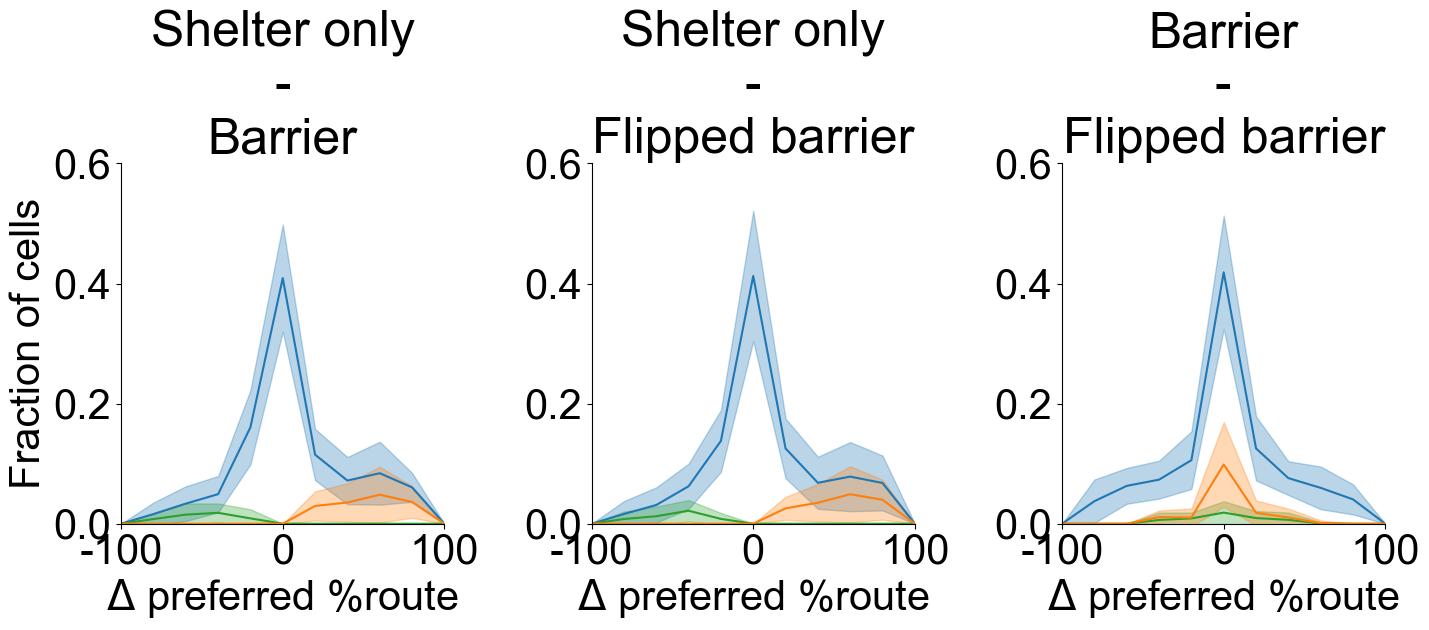

In [ ]:
""""Make a histogram of the difference in preferred tuning between conditions"""

fig, axs = plt.subplots(1, 3, figsize = (24, 8))
bin_center = hist_bins[:-1] + np.diff(hist_bins)/2
for idx, ax in enumerate(axs):
    ax.plot(bin_center, hist_all[:,:,idx].T, color = 'C0')
    # histogram of cells with pref tuning in barrier > pref tuning in shelter_only
    ax.plot(bin_center, hist_goal[:,:,idx].T, color = 'C2')
    # histogram of cells with pref tuning in shelter_only > pref tuning in barrier
    ax.plot(bin_center, hist_2nd_leg[:,:,idx].T, color = 'C1')
    ax.set_title(c_names[cond[0][idx]] + ' - ' + c_names[cond[1][idx]])
    if tuning_data == '':
        ax.set_xlim([-100,100])
    else:
        ax.set_xlim([-25,25])
        ax.set_ylim([0,0.7])
    ax.set_xlabel(r'$\Delta$ preferred % escape')
    if idx == 0:
        ax.set_ylabel(r'Fraction of cells')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xticks([-25,0,25])
    ax.set_xticklabels(['-100','0','100'])

plt.tight_layout()
figure_saver = Figure_Saver(dir_save=save_path, format_save=["pdf"], overwrite=True)
figure_saver.save(fig, name_file='Difference_Pref_tuning')

"""Make a histogram of the difference in preferred tuning between conditions, 
averages across sessions"""
fig, axs = plt.subplots(1, 3, figsize = (15, 7))
bin_center = hist_bins[:-1] + np.diff(hist_bins)/2
for idx, ax in enumerate(axs):
    # histogram of all neuron
    mean = np.nanmean(hist_all[:,:,idx], axis = 0)
    std = np.nanstd(hist_all[:,:,idx], axis = 0)
    ax.plot(bin_center, mean, color = 'C0', label = 'All')
    ax.fill_between(bin_center, mean-std, mean+std, color = 'C0', alpha = 0.3)
    # histogram of cells with pref tuning in barrier > pref tuning in shelter_only
    mean = np.nanmean(hist_goal[:,:,idx], axis = 0)
    std = np.nanstd(hist_goal[:,:,idx], axis = 0)
    ax.plot(bin_center, mean, color = 'C2', label = 'Shelter remap goal')
    ax.fill_between(bin_center, mean-std, mean+std, color = 'C2', alpha = 0.3)
    # histogram of cells with pref tuning in shelter_only > pref tuning in barrier
    mean = np.nanmean(hist_2nd_leg[:,:,idx], axis = 0)
    std = np.nanstd(hist_2nd_leg[:,:,idx], axis = 0)
    ax.plot(bin_center, mean, color = 'C1', label = 'Shelter remap 2nd leg')
    ax.fill_between(bin_center, mean-std, mean+std, color = 'C1', alpha = 0.3)
    ax.set_title(title_c_names[cond[0][idx]] + '\n - \n' + title_c_names[cond[1][idx]])
    if tuning_data == '':
        ax.set_xlim([-100,100])
    else:
        ax.set_xlim([-25,25])
        ax.set_ylim([0,0.6])
    ax.set_xlabel(r'$\Delta$ preferred %route')
    if idx == 0:
        ax.set_ylabel(r'Fraction of cells')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xticks([-25,0,25])
    ax.set_xticklabels(['-100','0','100'])
    # if idx == 0:
    #     ax.legend()

plt.tight_layout()
figure_saver = Figure_Saver(dir_save=save_path, format_save=["pdf"], overwrite=True)
figure_saver.save(fig, name_file='Difference_Pref_tuning_SeshAvg')

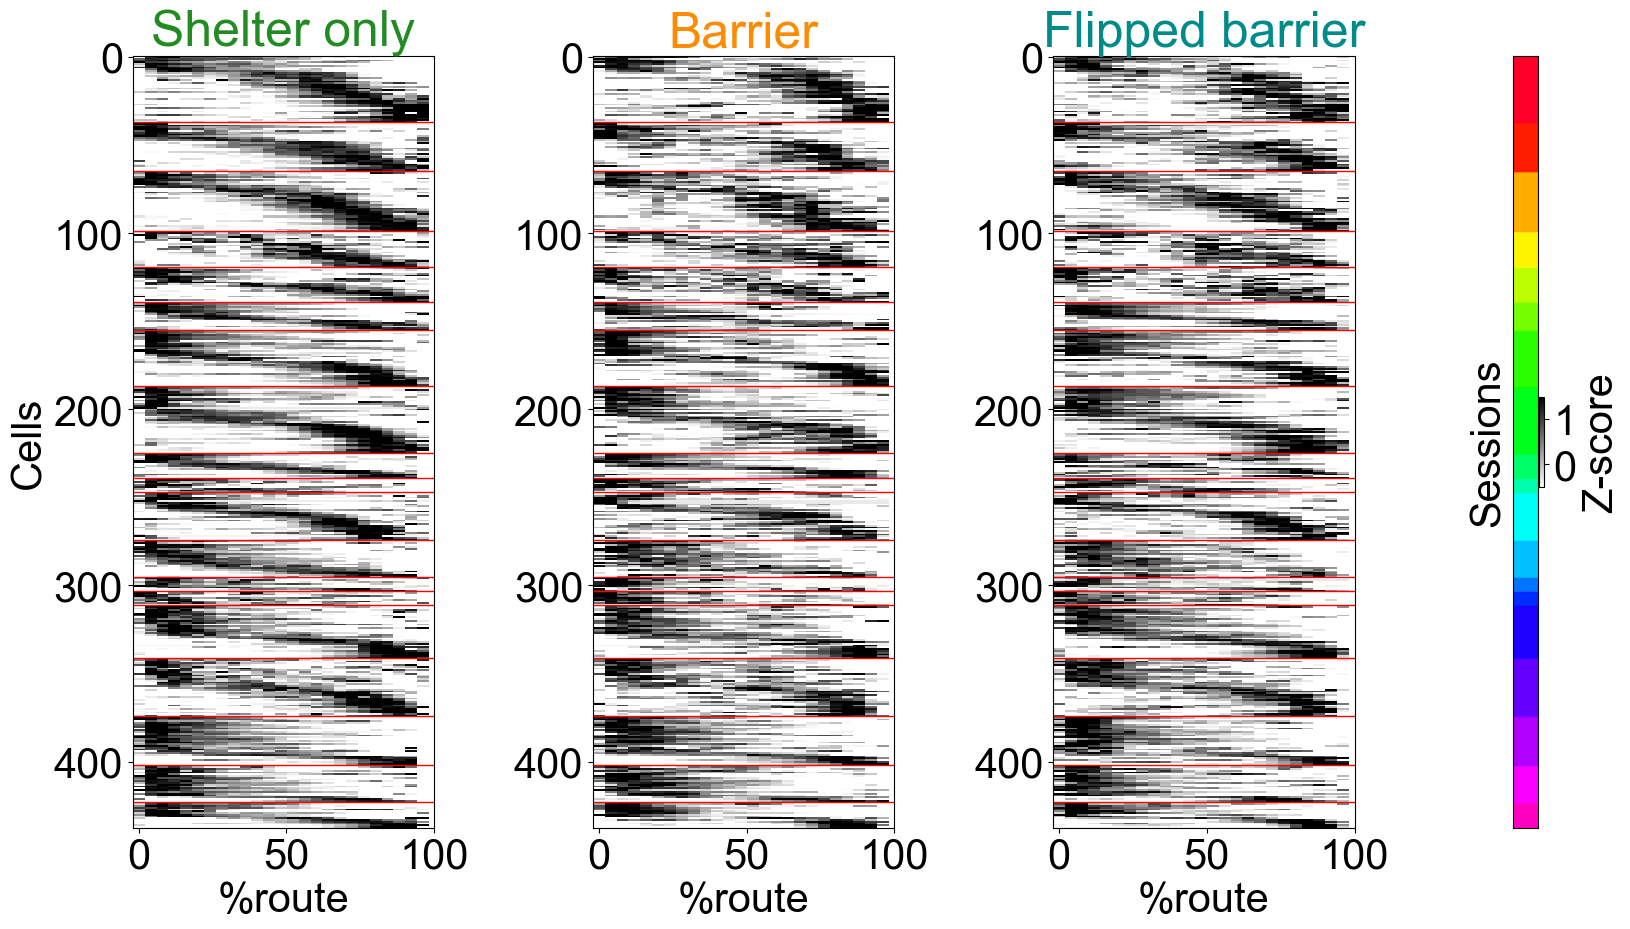

In [ ]:
"""For cells that don't change their tuning between conditions, align heatmaps"""

# diff are the cells that are consistent from shelter_only to barrier AND from barrier to flipped_barrier
diff = (np.abs(all_params[:, 0, 1] - all_params[:, 1, 1]) < threshold) & (np.abs(all_params[:, 1, 1] - all_params[:, 2, 1]) < threshold)
fr_cells = zscore(all_fr[:, all_cells & diff,:], axis = 2, nan_policy='omit')
sesh_cells = sesh_vector[all_cells & diff]
params_cells = all_params[all_cells & diff,:,:]

# re-sort the cells based on peak firing in each condition separately for each session
for i in np.unique(sesh_cells):
    idx = np.argsort(params_cells[sesh_cells == i, 0, 1])
    for c in range(3):
        resorted = fr_cells[c,sesh_cells == i,:]
        fr_cells[c, sesh_cells == i,:] = resorted[idx]

# find the cells where the session switches
switch_points = np.where(np.diff(sesh_cells) != 0)[0]
    
fig = plt.figure(figsize = (17, 10))
gs = gridspec.GridSpec(1, 4, width_ratios=[5, 5, 5, .5])

for idx in range(3):
    ax = fig.add_subplot(gs[:, idx])
    if idx == 0:
        ax.set_ylabel(r"Cells")
    if idx == 2:
        im = ax.imshow(fr_cells[idx, :, :], vmin = -.5, vmax = 1.5, cmap="gray_r", aspect="auto", interpolation = "none")
    else:
        ax.imshow(fr_cells[idx, :, :], vmin = -.5, vmax = 1.5, cmap="gray_r", aspect="auto", interpolation = "none")
    ax.set_title(title_c_names[idx], color = cond_colors[idx])
    if var == 'escape':
        ax.set_xlabel(r'%route')
        if tuning_data == '_25bins':
            ax.set_xticks([0,12.5,25])
            ax.set_xticklabels(['0','50','100'])
    ax.set_yticks(np.arange(0, fr_cells.shape[1], 100))
    for sp in switch_points:
        ax.axhline(sp, color = 'red', linewidth = 1)        

ax1 = fig.add_subplot(gs[:, 3])
ax1.imshow(sesh_cells[:, np.newaxis], cmap = 'gist_rainbow', aspect="auto")
ax1.set_xticks([])  # Hide x-axis ticks
ax1.set_yticks([])  # Hide y-axis ticks
ax1.set_ylabel('Sessions')

# Add colorbar after the third heatmap
cbar = plt.colorbar(im, ax=ax1, shrink=0.7)
cbar.set_label('Z-score')

plt.tight_layout()
figure_saver = Figure_Saver(dir_save=save_path, format_save=["pdf"], overwrite=True)
figure_saver.save(fig, name_file='Consistent_cells_heatmap')

""" A second plot for looking at the tuning curves of individual cells in one session"""
s = 7
fig = plt.figure(figsize = (17, 10))
gs = gridspec.GridSpec(1, 4, width_ratios=[5, 5, 5, .5])
colors = plt.cm.cool(np.linspace(0, 1, np.sum(sesh_cells == s)))

for idx in range(3):
    ax = fig.add_subplot(gs[:, idx])
    if idx == 0:
        ax.set_ylabel(r"Cells")
    fr_sesh = fr_cells[idx, sesh_cells == s, :]

    for i, m in enumerate(fr_sesh):
        ax.plot(m - i, color=colors[i])
        ax.scatter(np.argmax(m, axis = 0), np.max(m, axis = 0) - i, color = colors[i], s = 50)
    if var == 'escape':
        ax.set_xlabel(r'%route')
    if tuning_data == '_25bins':
        ax.set_xticks([0,12.5,25])
        ax.set_xticklabels(['0','50','100'])
    ax.set_title(title_c_names[idx], color = cond_colors[idx])
    ax.set_yticks([])
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.tight_layout()

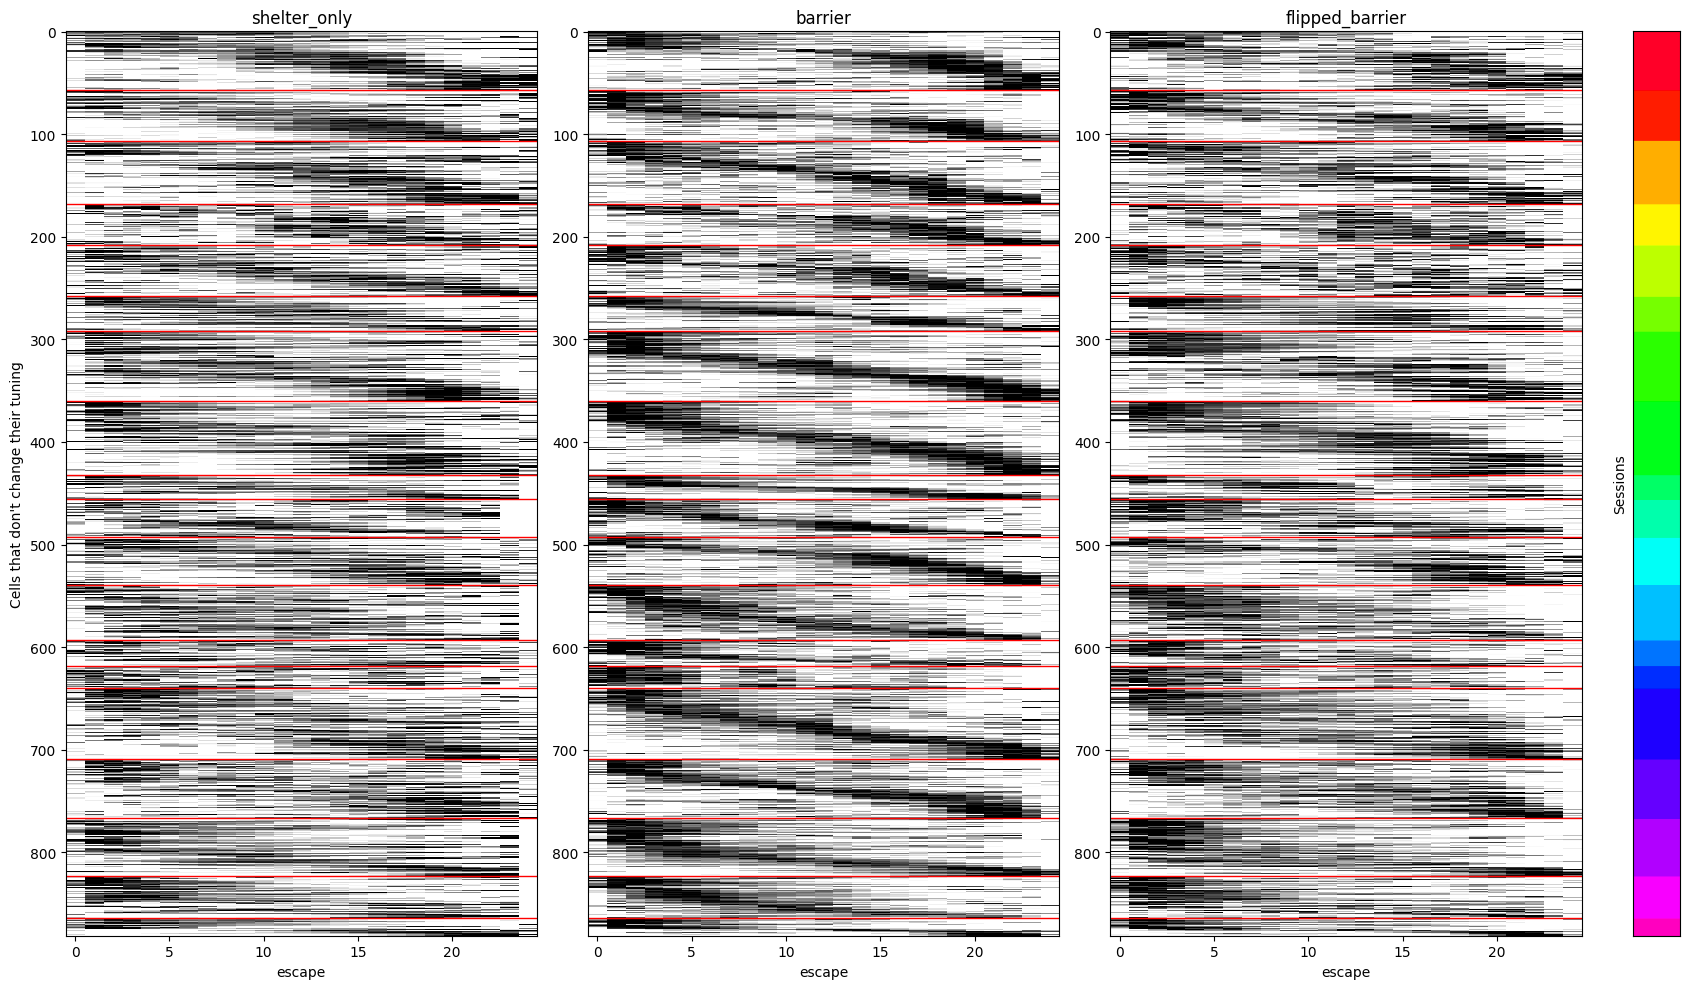

In [ ]:
"""For cells that are sig in all conditions and only don't change their tuning between barrier conditions, align barrier heatmaps"""

# diff are the cells that are consistent from shelter_only to barrier AND from barrier to flipped_barrier
diff = (np.abs(all_params[:, 1, 1] - all_params[:, 2, 1]) < threshold)
fr_cells = zscore(all_fr[:, all_cells & diff,:], axis = 2, nan_policy='omit')
sesh_cells = sesh_vector[all_cells & diff]
params_cells = all_params[all_cells & diff,:,:]

# re-sort the cells based on peak firing in each condition separately for each session
for i in np.unique(sesh_cells):
    idx = np.argsort(params_cells[sesh_cells == i, 1, 1])
    for c in range(3):
        resorted = fr_cells[c,sesh_cells == i,:]
        fr_cells[c, sesh_cells == i,:] = resorted[idx]

# find the cells where the session switches
switch_points = np.where(np.diff(sesh_cells) != 0)[0]
    
fig = plt.figure(figsize = (17, 10))
gs = gridspec.GridSpec(1, 4, width_ratios=[5, 5, 5, .5])

for idx in range(3):
    ax = fig.add_subplot(gs[:, idx])
    if idx == 0:
        ax.set_ylabel(r"Cells that don't change their tuning")
    ax.imshow(fr_cells[idx, :, :], vmin = -.5, vmax = 1.5, cmap="gray_r", aspect="auto", interpolation = "none")
    ax.set_title(c_names[idx])
    ax.set_xlabel(var)
    for sp in switch_points:
        ax.axhline(sp, color = 'red', linewidth = 1)

ax1 = fig.add_subplot(gs[:, 3])
ax1.imshow(sesh_cells[:, np.newaxis], cmap = 'gist_rainbow', aspect="auto")
ax1.set_xticks([])  # Hide x-axis ticks
ax1.set_yticks([])  # Hide y-axis ticks
ax1.set_ylabel('Sessions')

plt.tight_layout()

Cells that remap their tuning between shelter and both barrier conditions
- group1: cells with negative difference in tuning between shelter and barrier (is their pref tuning to shelter now a pref tuning to barrier?)
- group2: cells with positive difference in tuning between shelter and barrier (is their pref tuning to shelter now a pref tuning from barrier to shelter?)

In [82]:
"""Extract data and get tuning curves for the first or second leg of the homing"""
%autoreload 2
compressions = ['escape_shelter', 'escape_first_goal']
Nbins = all_fr.shape[2]
bins = np.append(np.arange(0,1,1/Nbins), 1+1e-10)

fr_shelt = np.full_like(all_fr, np.nan)
fr_goal = np.full_like(all_fr, np.nan)
fit_shelt = np.full_like(all_fr, np.nan)
fit_goal = np.full_like(all_fr, np.nan)
params_shelt = np.full_like(all_params, np.nan)
params_goal = np.full_like(all_params, np.nan)
counter = 0

for e, exp in enumerate(experiments_objects):
    # 3. load in neural data
    session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, escape, outofshelter = load(exp)
    ons, offs, homie = load_homing(session, len(behave))
    fcm = gaussian_filter1d(frame_by_cluster_matrix, 2, axis = 0)
    # fcm = fcm[:, all_cells[sesh_vector == e]]
    for cv in compressions:
        frac_escape, escape_matrix, c, h_start = extract_homing_and_escape_periods(session, 
                                                                                        fcm, 
                                                                                        behave, 
                                                                                        y_pos, 
                                                                                        x_pos, 
                                                                                        bar, # should this also be shifted?!?! 
                                                                                        barflip, 
                                                                                        cv, 
                                                                                        ons, offs,
                                                                                        bins = bins,
                                                                                        no_stationary = False, 
                                                                                        return_escape = False,
                                                                                        zscore = False)

        # initialize vars
        n_neur = fcm.shape[1]
        n_cond = len(np.unique(c_names))

        fit_real_exp, _, fr_real_exp, params_real_exp, _ = tuning_method(frac_escape, 
                                                                        escape_matrix, 
                                                                        c, 
                                                                        h_start, 
                                                                        Nbins, 
                                                                        n_cond,
                                                                        n_neur,
                                                                        fitting = False)
        
        if cv == 'escape_shelter':
            fr_shelt[:,counter:counter+fr_real_exp.shape[1],:] = fr_real_exp
            fit_shelt[:,counter:counter+fr_real_exp.shape[1],:] = fit_real_exp
            params_shelt[counter:counter+fr_real_exp.shape[1],:,:] = params_real_exp
        elif cv == 'escape_first_goal':
            fr_goal[:,counter:counter+fr_real_exp.shape[1],:] = fr_real_exp
            fit_goal[:,counter:counter+fr_real_exp.shape[1],:] = fit_real_exp
            params_goal[counter:counter+fr_real_exp.shape[1],:,:] = params_real_exp
    
    counter += fr_real_exp.shape[1]

2025-03-24 10:35:25.467 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-03-24 10:36:17.534 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-03-24 10:37:03.919 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-03-24 10:38:04.705 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-03-24 10:39:05.928 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-03-24 10:40:12.241 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-03-24 10:41:08.895 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-03-24 10:43:32.407 | INFO     | behave_analysis.utils.dat

In [128]:
"""Define the two groups"""
consistent = (np.abs(all_params[:, 0, 1] - all_params[:, 1, 1]) < threshold) & (np.abs(all_params[:, 1, 1] - all_params[:, 2, 1]) < threshold)

# group1: cells with positive difference in tuning between shelter and barrier (shelter > barrier)
# is their pref tuning to shelter now a pref tuning to barrier?
# these will remap to fr_goal
all_diff_g1 = ((all_params[:, 0, 1] - all_params[:, 1, 1]) > threshold) & ((all_params[:, 0, 1] - all_params[:, 2, 1]) > threshold)

# group2: cells with negative difference in tuning between shelter and barrier (barrier > shelter)
# is their pref tuning to shelter now a pref tuning to shelter from barrier?
# these should be compared to fr_shelt
all_diff_g2 = ((all_params[:, 0, 1] - all_params[:, 1, 1]) < - threshold) & ((all_params[:, 0, 1] - all_params[:, 2, 1]) < - threshold)

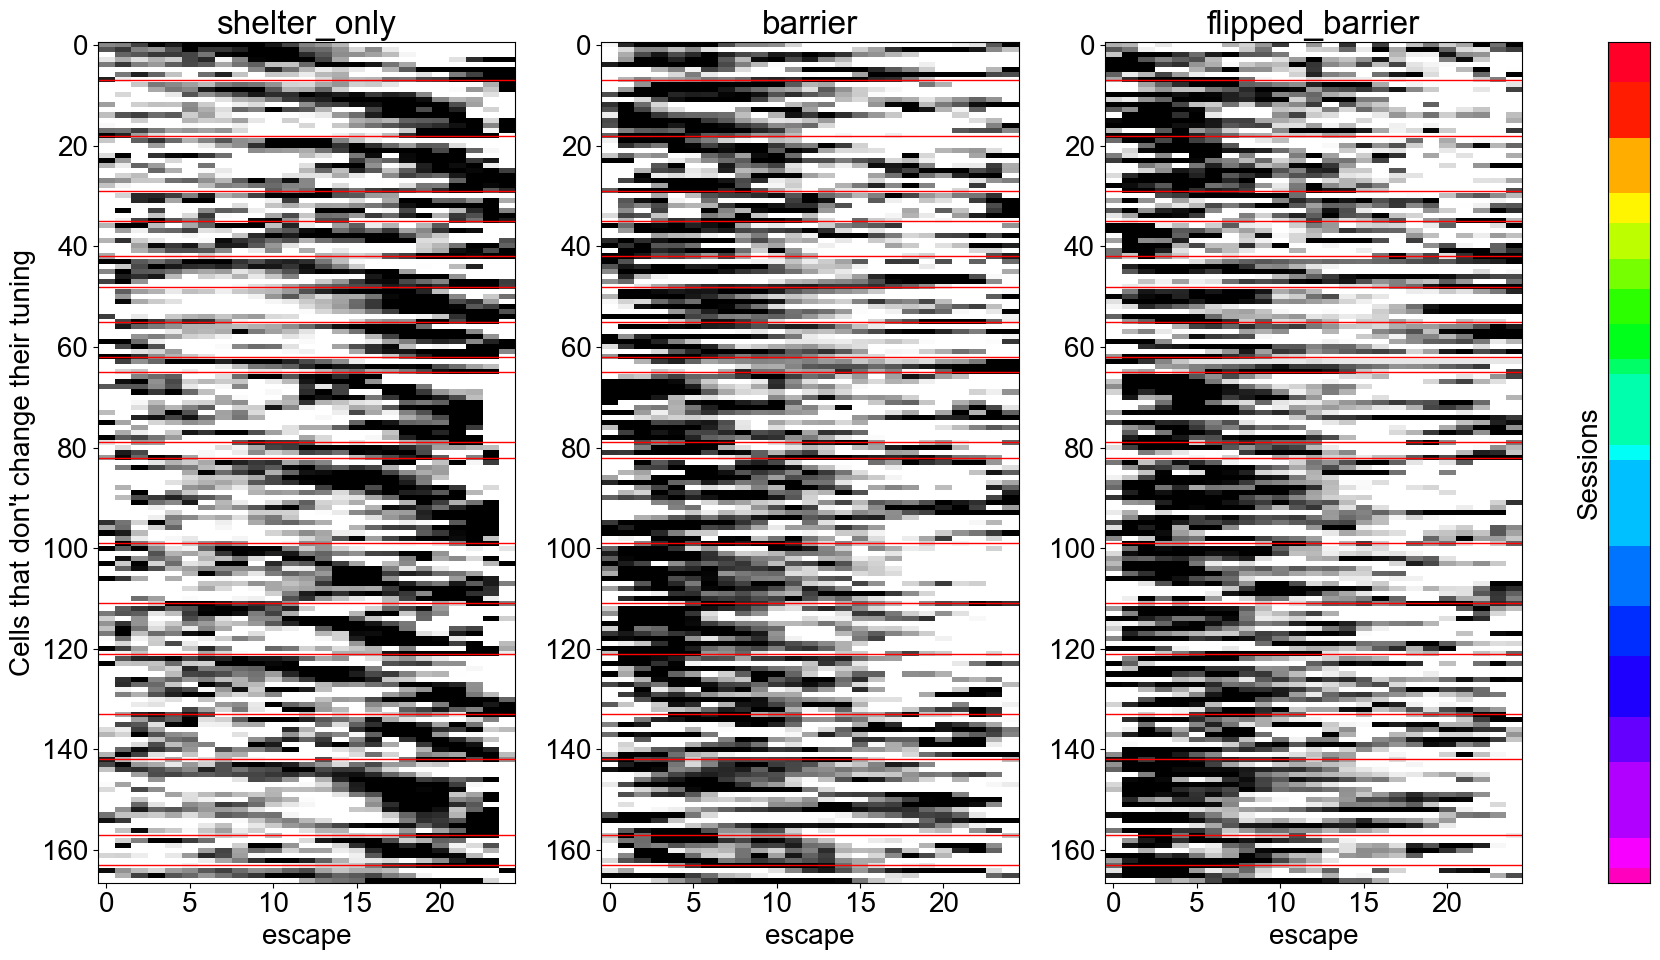

In [130]:
"""Cells that remap their tuning between shelter and both barrier conditions
group1: cells with positive difference in tuning between shelter and barrier (is their pref tuning to shelter now a pref tuning to barrier?)"""

assert var == 'escape', r"This needs to be escape or the logic won't work"

# diff are the cells that are consistent from shelter_only to barrier AND from barrier to flipped_barrier
fr_cells = zscore(all_fr[:, all_cells & all_diff_g1,:], axis = 2, nan_policy='omit')
sesh_cells = sesh_vector[all_cells & all_diff_g1]
params_cells = all_params[all_cells & all_diff_g1,:,:]
fr_goal_cells = zscore(fr_goal[:, all_cells & all_diff_g1,:], axis = 2, nan_policy='omit')
params_goal_cells = params_goal[all_cells & all_diff_g1,:,:]

# re-sort the cells based on peak firing in each condition separately for each session
# what we want to plot is the tuning to the full escape for shelter only and the tuning to barrier for both barrier conditions
fr_plot = np.concatenate((fr_cells[0:1,:,:], fr_goal_cells[1:,:,:]), axis = 0)
for i in np.unique(sesh_cells):
    idx = np.argsort(params_cells[sesh_cells == i, 0, 1])
    for c in range(3):
        resorted = fr_plot[c,sesh_cells == i,:]
        fr_plot[c, sesh_cells == i,:] = resorted[idx]

# find the cells where the session switches
switch_points = np.where(np.diff(sesh_cells) != 0)[0]
    
fig = plt.figure(figsize = (17, 10))
gs = gridspec.GridSpec(1, 4, width_ratios=[5, 5, 5, .5])

for idx in range(3):
    ax = fig.add_subplot(gs[:, idx])
    if idx == 0:
        ax.set_ylabel(r"Cells that don't change their tuning")
    ax.imshow(fr_plot[idx, :, :], vmin = -.5, vmax = 1, cmap="gray_r", aspect="auto", interpolation = "none")
    ax.set_title(c_names[idx])
    ax.set_xlabel(var)
    for sp in switch_points:
        ax.axhline(sp, color = 'red', linewidth = 1)

ax1 = fig.add_subplot(gs[:, 3])
ax1.imshow(sesh_cells[:, np.newaxis], cmap = 'gist_rainbow', aspect="auto")
ax1.set_xticks([])  # Hide x-axis ticks
ax1.set_yticks([])  # Hide y-axis ticks
ax1.set_ylabel('Sessions')

plt.tight_layout()



RH Warning: Overwriting file. File: \\ceph-gw02.hpc.swc.ucl.ac.uk\branco\Jasmine_Laurence\summary_plots\Cosyne\Difference_Pref_tuning_SeshAvg_Remap_Goal.pdf already exists.


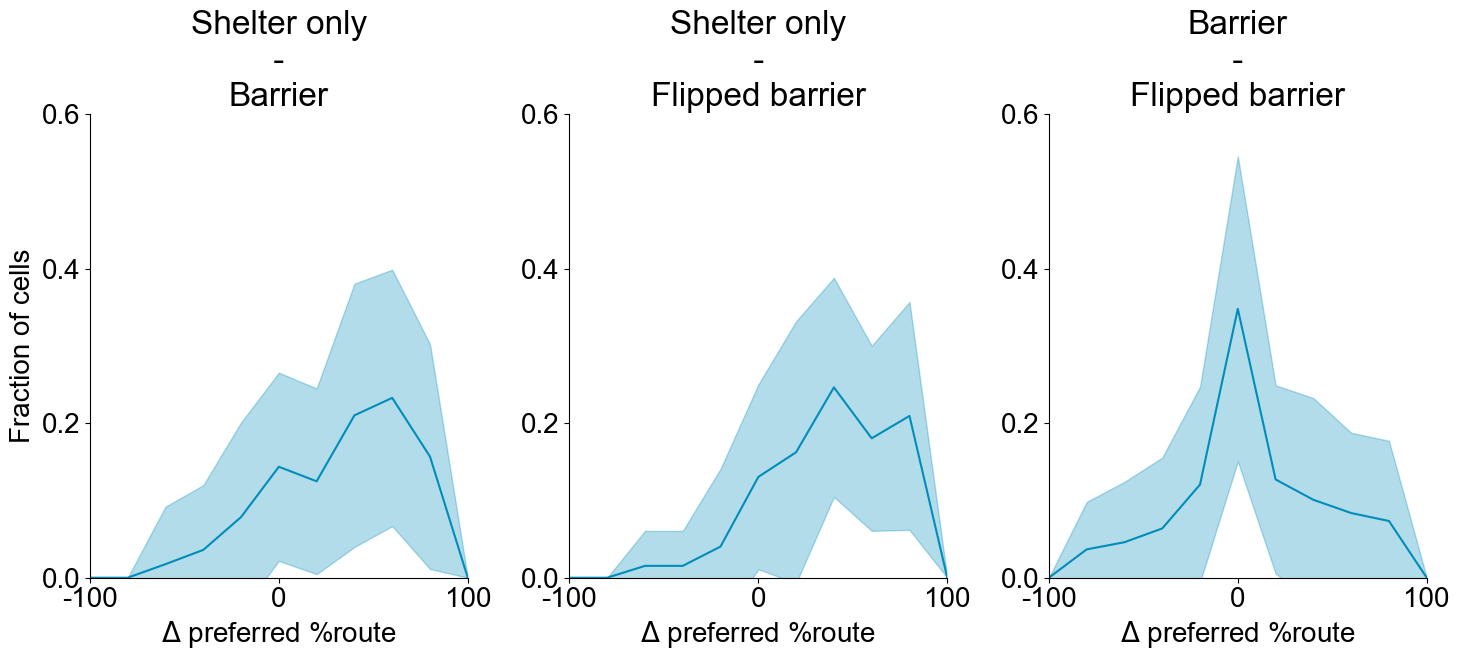

In [131]:
"""Make a histogram of the difference in preferred tuning across conditions, 
averages across sessions for cells that remap to the first leg"""

# diff are the cells that are consistent from shelter_only to barrier AND from barrier to flipped_barrier
sesh_cells = sesh_vector[all_cells & all_diff_g1]
params_cells = all_params[all_cells & all_diff_g1,:,:]
# diff and all_diff select the same cells, but depending on how many cells we have
params_goal_cells = params_goal[all_cells & all_diff_g1,:,:]

for s in np.unique(sesh_cells):
    # full shelter tuning - tuning to first leg in barrier
    diff = params_cells[sesh_cells == s, 0, 1] - params_goal_cells[sesh_cells == s, 1, 1]
    hist_all[s,:,0], _ = np.histogram(diff, bins = hist_bins)
    hist_all[s,:,0] = hist_all[s,:,0]/np.sum(hist_all[s,:,0])
    # full shelter tuning - tuning to first leg in fipped barrier
    diff = params_cells[sesh_cells == s, 0, 1] - params_goal_cells[sesh_cells == s, 2, 1]
    hist_all[s,:,1], _ = np.histogram(diff, bins = hist_bins)
    hist_all[s,:,1] = hist_all[s,:,1]/np.sum(hist_all[s,:,1])
    # tuning to first leg in barrier - tuning to first leg in flipped barrier
    diff = params_goal_cells[sesh_cells == s, 1, 1] - params_goal_cells[sesh_cells == s, 2, 1]
    hist_all[s,:,2], _ = np.histogram(diff, bins = hist_bins)
    hist_all[s,:,2] = hist_all[s,:,2]/np.sum(hist_all[s,:,2])

fig, axs = plt.subplots(1, 3, figsize = (15, 7))
bin_center = hist_bins[:-1] + np.diff(hist_bins)/2
for idx, ax in enumerate(axs):
    # histogram of all neuron
    mean = np.nanmean(hist_all[:,:,idx], axis = 0)
    std = np.nanstd(hist_all[:,:,idx], axis = 0)
    ax.plot(bin_center, mean, color = '#008DB9', label = 'All')
    ax.fill_between(bin_center, mean-std, mean+std, color = '#008DB9', alpha = 0.3)
    ax.set_title(title_c_names[cond[0][idx]] + '\n - \n' + title_c_names[cond[1][idx]])
    if tuning_data == '':
        ax.set_xlim([-100,100])
    else:
        ax.set_xlim([-25,25])
        ax.set_ylim([0,0.6])
    ax.set_xlabel(r'$\Delta$ preferred %route')
    if idx == 0:
        ax.set_ylabel(r'Fraction of cells')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xticks([-25,0,25])
    ax.set_xticklabels(['-100','0','100'])
    # if idx == 0:
    #     ax.legend()

plt.tight_layout()
figure_saver = Figure_Saver(dir_save=save_path, format_save=["pdf"], overwrite=True)
figure_saver.save(fig, name_file='Difference_Pref_tuning_SeshAvg_Remap_Goal')

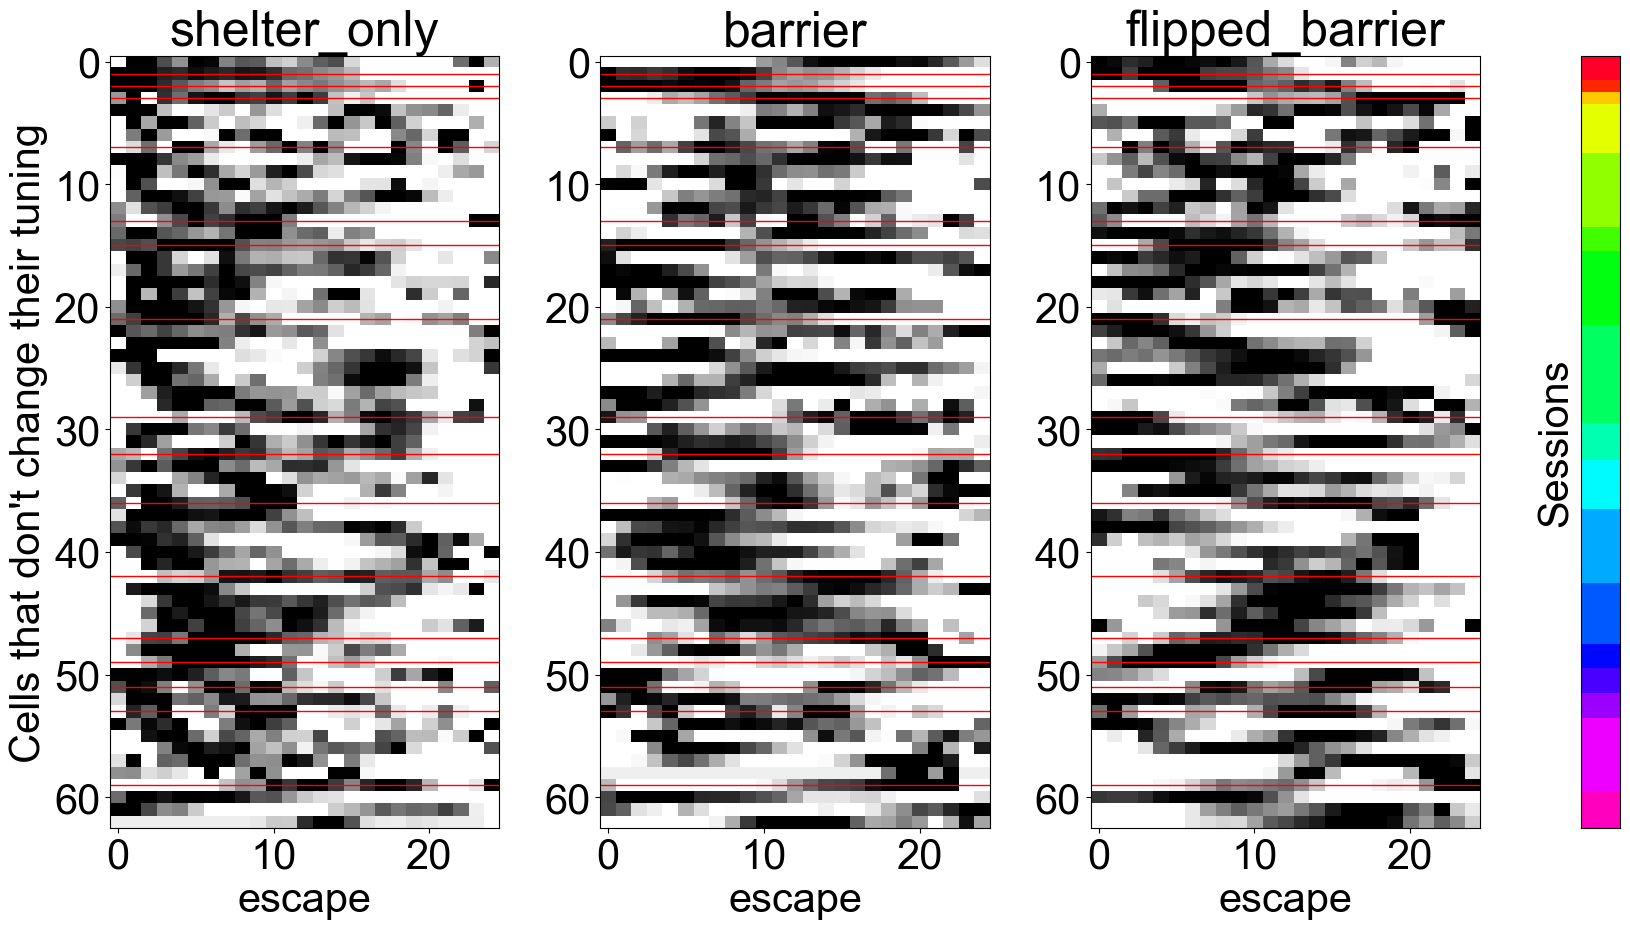

In [132]:
"""Cells that remap their tuning between shelter and both barrier conditions
group2: cells with negative difference in tuning between shelter and barrier (is their pref tuning to shelter now a pref tuning from barrier to shelter?)"""

# diff are the cells that are consistent from shelter_only to barrier AND from barrier to flipped_barrier
fr_cells = zscore(all_fr[:, all_cells & all_diff_g2,:], axis = 2, nan_policy='omit')
sesh_cells = sesh_vector[all_cells & all_diff_g2]
params_cells = all_params[all_cells & all_diff_g2,:,:]
fr_shelt_cells = zscore(fr_shelt[:, all_cells & all_diff_g2,:], axis = 2, nan_policy='omit')
params_shelt_cells = params_shelt[all_cells & all_diff_g2,:,:]

# re-sort the cells based on peak firing in each condition separately for each session
# what we want to plot is the tuning to the full escape for shelter only and the tuning to barrier for both barrier conditions
fr_plot = np.concatenate((fr_cells[0:1,:,:], fr_shelt_cells[1:,:,:]), axis = 0)
for i in np.unique(sesh_cells):
    idx = np.argsort(params_cells[sesh_cells == i, 0, 1])
    for c in range(3):
        resorted = fr_plot[c,sesh_cells == i,:]
        fr_plot[c, sesh_cells == i,:] = resorted[idx]

# find the cells where the session switches
switch_points = np.where(np.diff(sesh_cells) != 0)[0]
    
fig = plt.figure(figsize = (17, 10))
gs = gridspec.GridSpec(1, 4, width_ratios=[5, 5, 5, .5])

for idx in range(3):
    ax = fig.add_subplot(gs[:, idx])
    if idx == 0:
        ax.set_ylabel(r"Cells that don't change their tuning")
    ax.imshow(fr_plot[idx, :, :], vmin = -.5, vmax = 1, cmap="gray_r", aspect="auto", interpolation = "none")
    ax.set_title(c_names[idx])
    ax.set_xlabel(var)
    for sp in switch_points:
        ax.axhline(sp, color = 'red', linewidth = 1)

ax1 = fig.add_subplot(gs[:, 3])
ax1.imshow(sesh_cells[:, np.newaxis], cmap = 'gist_rainbow', aspect="auto")
ax1.set_xticks([])  # Hide x-axis ticks
ax1.set_yticks([])  # Hide y-axis ticks
ax1.set_ylabel('Sessions')

plt.tight_layout()

RH Warning: Overwriting file. File: \\ceph-gw02.hpc.swc.ucl.ac.uk\branco\Jasmine_Laurence\summary_plots\Cosyne\Difference_Pref_tuning_SeshAvg_Remap_2ndleg.pdf already exists.


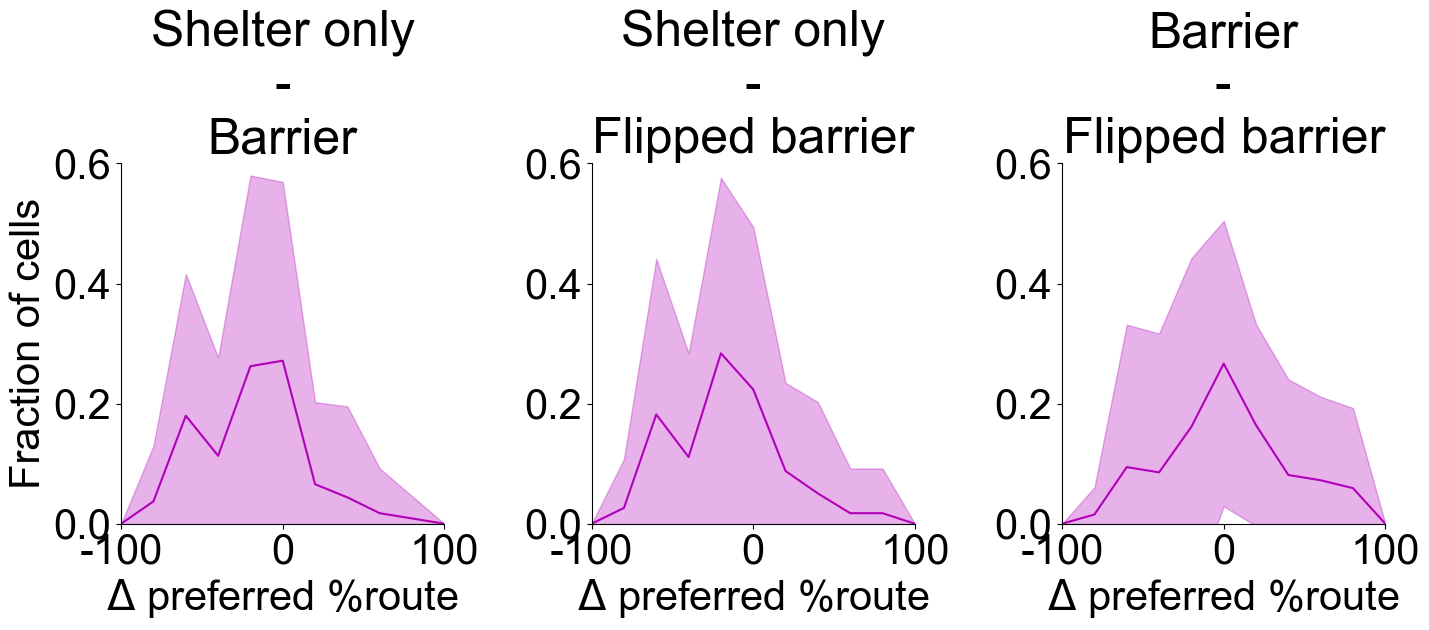

In [133]:
"""Make a histogram of the difference in preferred tuning across conditions, 
averages across sessions for cells that remap to the second leg"""

# diff are the cells that are consistent from shelter_only to barrier AND from barrier to flipped_barrier
sesh_cells = sesh_vector[all_cells & all_diff_g2]
params_cells = all_params[all_cells & all_diff_g2,:,:]
params_shelt_cells = params_shelt[all_cells & all_diff_g2,:,:]

for s in np.unique(sesh_cells):
    # full shelter tuning - tuning to first leg in barrier
    diff = params_cells[sesh_cells == s, 0, 1] - params_shelt_cells[sesh_cells == s, 1, 1]
    hist_all[s,:,0], _ = np.histogram(diff, bins = hist_bins)
    hist_all[s,:,0] = hist_all[s,:,0]/np.sum(hist_all[s,:,0])
    # full shelter tuning - tuning to first leg in fipped barrier
    diff = params_cells[sesh_cells == s, 0, 1] - params_shelt_cells[sesh_cells == s, 2, 1]
    hist_all[s,:,1], _ = np.histogram(diff, bins = hist_bins)
    hist_all[s,:,1] = hist_all[s,:,1]/np.sum(hist_all[s,:,1])
    # tuning to first leg in barrier - tuning to first leg in flipped barrier
    diff = params_shelt_cells[sesh_cells == s, 1, 1] - params_shelt_cells[sesh_cells == s, 2, 1]
    hist_all[s,:,2], _ = np.histogram(diff, bins = hist_bins)
    hist_all[s,:,2] = hist_all[s,:,2]/np.sum(hist_all[s,:,2])

fig, axs = plt.subplots(1, 3, figsize = (15, 7))
bin_center = hist_bins[:-1] + np.diff(hist_bins)/2
for idx, ax in enumerate(axs):
    # histogram of all neuron
    mean = np.nanmean(hist_all[:,:,idx], axis = 0)
    std = np.nanstd(hist_all[:,:,idx], axis = 0)
    ax.plot(bin_center, mean, color = '#B100B9', label = 'All')
    ax.fill_between(bin_center, mean-std, mean+std, color = '#B100B9', alpha = 0.3)
    ax.set_title(title_c_names[cond[0][idx]] + '\n - \n' + title_c_names[cond[1][idx]])
    if tuning_data == '':
        ax.set_xlim([-100,100])
    else:
        ax.set_xlim([-25,25])
        ax.set_ylim([0,0.6])
    ax.set_xlabel(r'$\Delta$ preferred %route')
    if idx == 0:
        ax.set_ylabel(r'Fraction of cells')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xticks([-25,0,25])
    ax.set_xticklabels(['-100','0','100'])
    # if idx == 0:
    #     ax.legend()

plt.tight_layout()
figure_saver = Figure_Saver(dir_save=save_path, format_save=["pdf"], overwrite=True)
figure_saver.save(fig, name_file='Difference_Pref_tuning_SeshAvg_Remap_2ndleg')

In [134]:
"""Make a plot for an example neuron of the tuning curve remapping"""

s = 7
idx = 13
neur = np.where(sesh_vector == s)[0][idx]

colors = [
    "#264653",  # Dark Blue - doesn't remap
    '#008DB9', # Light Blue - remaps to goal
    '#B100B9' # Pink - remaps to 2nd leg
]

matplotlib.rcParams['font.size'] = 20
remap_path = make_directory("Z:/Jasmine_Laurence/summary_plots/Cosyne/TuningCurveRemap/")

for neur in range(all_fit.shape[1]):
    if all_cells[neur] == True:
        session = sesh_vector[neur]
        id_in_sesh = np.where(np.where(sesh_vector == session)[0] == neur)[0][0]

        fig, axs = plt.subplots(3, 3, figsize = (15, 15))

        """First row, compare the conditions in the full route"""
        # get the max firing rate for the neuron for all three plots
        max_fr = np.max([np.nanmax(all_fit[:,neur,:])])

        for c in range(3):
            axs[0, c].plot(all_fit[c, neur, :], color=colors[0], linewidth=2)
            axs[0, c].set_xlabel(r'% route')
            axs[0, c].set_xticks([0, (all_fit.shape[2]) / 2, all_fit.shape[2]])
            axs[0, c].set_xticklabels(['0', '50', '100'])

        axs[0,0].set_ylabel('Firing Rate (Hz)')
        for i in range(3):
            axs[0,i].set_ylim([0, max_fr])

        """Second row, plot shelter_only full route compared to barrier first leg"""
        # get the max firing rate for the neuron for all three plots
        max_fr = np.max([np.nanmax(all_fit[0,neur,:]), np.nanmax(fit_goal[1,neur,:]), np.nanmax(fit_goal[2,neur,:])])

        axs[1,0].plot(all_fit[0,neur,:], color = cond_colors[0], linewidth = 2)
        axs[1,0].set_xlabel(r'% route')
        axs[1,0].set_xticks([0, (all_fit.shape[2])/2, all_fit.shape[2]])
        axs[1,0].set_xticklabels(['0', '50', '100'])

        for i in range(2):
            i += 1
            axs[1,i].plot(fit_goal[i,neur,:], color = colors[1], linewidth = 2)
            axs[1,i].set_xlabel(r'% route to barrier')
            axs[1,i].set_xticks([0, (fit_goal.shape[2])/2, fit_goal.shape[2]])
            axs[1,i].set_xticklabels(['0', '50', '100'])

        axs[1,0].set_ylabel('Firing Rate (Hz)')
        for i in range(3):
            axs[1,i].set_ylim([0, max_fr])

        """Third row, plot shelter_only full route compared to barrier first leg"""
        # get the max firing rate for the neuron for all three plots
        max_fr = np.max([np.nanmax(all_fit[0,neur,:]), np.nanmax(fit_shelt[1,neur,:]), np.nanmax(fit_shelt[2,neur,:])])

        axs[2,0].plot(all_fit[0,neur,:], color = cond_colors[0], linewidth = 2)
        axs[2,0].set_xlabel(r'% route')
        axs[2,0].set_xticks([0, (all_fit.shape[2])/2, all_fit.shape[2]])
        axs[2,0].set_xticklabels(['0', '50', '100'])

        for i in range(2):
            i += 1
            axs[2,i].plot(fit_shelt[i,neur,:], color = colors[2], linewidth = 2)
            axs[2,i].set_xlabel(r'% route to shelter')
            axs[2,i].set_xticks([0, (fit_shelt.shape[2])/2, fit_shelt.shape[2]])
            axs[2,i].set_xticklabels(['0', '50', '100'])

        axs[2,0].set_ylabel('Firing Rate (Hz)')
        for i in range(3):
            axs[2,i].set_ylim([0, max_fr])

        for ax in axs.flat:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

        plt.tight_layout()
        if all_diff_g1[neur] == True:
            title = session_names[session] + '_TuningCurves_Neuron_' + str(id_in_sesh) + '_RemapGoal'
        elif all_diff_g2[neur] == True:
            title = session_names[session] + '_TuningCurves_Neuron_' + str(id_in_sesh) + '_Remap2ndLeg'
        elif consistent[neur] == True:
            title = session_names[session] + '_TuningCurves_Neuron_' + str(id_in_sesh) + '_Consistent'
        fig.savefig(remap_path + "\\" + title + '.png', format='png', dpi=300)
        plt.close()

In [137]:
"""Make a plot for an example neuron of the tuning curve remapping"""

s = 7
idx = 13
neur = [261,55,142,231,4, # consistent
        34,201,189,191,229, # remap to goal
        34,220,293,105,295 # remap to 2nd leg
        ]
sesh = [0,3,3,4,17, # consistent
        0,0,11,11,12, # remap to goal
        0,0,3,4,4 # remap to 2nd leg
        ]
neur = [4]
sesh = [17]
colors = [
    "#264653",  # Dark Blue - doesn't remap
    '#008DB9', # Light Blue - remaps to goal
    '#B100B9' # Pink - remaps to 2nd leg
]

matplotlib.rcParams['font.size'] = 20
remap_path = make_directory("Z:/Jasmine_Laurence/summary_plots/Cosyne/TuningCurveRemap/")

for n,s in zip(neur,sesh):
    neur = np.where(sesh_vector == s)[0][n]
    session = sesh_vector[neur]
    id_in_sesh = np.where(np.where(sesh_vector == session)[0] == neur)[0][0]

    fig, axs = plt.subplots(3, 3, figsize = (10, 12))

    """First row, compare the conditions in the full route"""
    # get the max firing rate for the neuron for all three plots
    max_fr = np.max([np.nanmax(all_fit[:,neur,:])])

    for c in range(3):
        axs[0, c].plot(all_fit[c, neur, :], color=colors[0], linewidth=2)
        axs[0, c].set_xlabel(r'% route')
        axs[0, c].set_xticks([0, (all_fit.shape[2]) / 2, all_fit.shape[2]])
        axs[0, c].set_xticklabels(['0', '50', '100'])

    axs[0,0].set_ylabel('Firing Rate (Hz)')
    for i in range(3):
        axs[0,i].set_ylim([0, max_fr])

    """Second row, plot shelter_only full route compared to barrier first leg"""
    # get the max firing rate for the neuron for all three plots
    max_fr = np.max([np.nanmax(all_fit[0,neur,:]), np.nanmax(fit_goal[1,neur,:]), np.nanmax(fit_goal[2,neur,:])])

    axs[1,0].plot(all_fit[0,neur,:], color = cond_colors[0], linewidth = 2)
    axs[1,0].set_xlabel(r'% route')
    axs[1,0].set_xticks([0, (all_fit.shape[2])/2, all_fit.shape[2]])
    axs[1,0].set_xticklabels(['0', '50', '100'])

    for i in range(2):
        i += 1
        axs[1,i].plot(fit_goal[i,neur,:], color = colors[1], linewidth = 2)
        axs[1,i].set_xlabel(r'% route to barrier')
        axs[1,i].set_xticks([0, (fit_goal.shape[2])/2, fit_goal.shape[2]])
        axs[1,i].set_xticklabels(['0', '50', '100'])

    axs[1,0].set_ylabel('Firing Rate (Hz)')
    for i in range(3):
        axs[1,i].set_ylim([0, max_fr])

    """Third row, plot shelter_only full route compared to barrier first leg"""
    # get the max firing rate for the neuron for all three plots
    max_fr = np.max([np.nanmax(all_fit[0,neur,:]), np.nanmax(fit_shelt[1,neur,:]), np.nanmax(fit_shelt[2,neur,:])])

    axs[2,0].plot(all_fit[0,neur,:], color = cond_colors[0], linewidth = 2)
    axs[2,0].set_xlabel(r'% route')
    axs[2,0].set_xticks([0, (all_fit.shape[2])/2, all_fit.shape[2]])
    axs[2,0].set_xticklabels(['0', '50', '100'])

    for i in range(2):
        i += 1
        axs[2,i].plot(fit_shelt[i,neur,:], color = colors[2], linewidth = 2)
        axs[2,i].set_xlabel(r'% route to shelter')
        axs[2,i].set_xticks([0, (fit_shelt.shape[2])/2, fit_shelt.shape[2]])
        axs[2,i].set_xticklabels(['0', '50', '100'])

    axs[2,0].set_ylabel('Firing Rate (Hz)')
    for i in range(3):
        axs[2,i].set_ylim([0, max_fr])

    for ax in axs.flat:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    if all_diff_g1[neur] == True:
        title = session_names[session] + '_TuningCurves_Neuron_' + str(id_in_sesh) + '_RemapGoal'
    elif all_diff_g2[neur] == True:
        title = session_names[session] + '_TuningCurves_Neuron_' + str(id_in_sesh) + '_Remap2ndLeg'
    elif consistent[neur] == True:
        title = session_names[session] + '_TuningCurves_Neuron_' + str(id_in_sesh) + '_Consistent'
    
    figure_saver = Figure_Saver(dir_save=save_path, format_save=["pdf"], overwrite=True)
    figure_saver.save(fig, name_file=title)

    plt.close()